# 1. Install deap for non-gradient-based optimisation algorithms

In [ ]:
!pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 7.0 MB/s eta 0:00:00


# 2. Load CIFAR10

In [1]:
# Load and normalise CIFAR10

import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import models

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 64

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:04<00:00, 41.0MB/s]


# 3. Verify data loaded correctly by displaying a few images

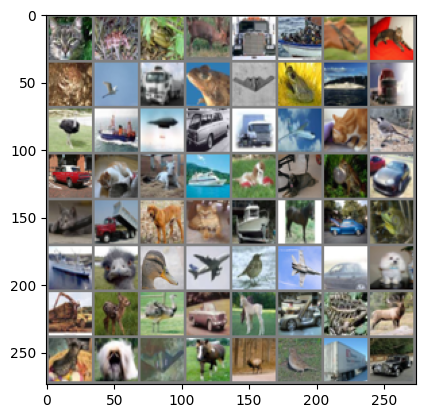

cat   frog  frog  deer  truck ship  horse cat   frog  bird  truck frog  plane frog  ship  truck bird  ship  plane car   truck plane cat   bird  car   cat   horse ship  dog   dog   frog  car   cat   truck dog   cat   ship  horse car   frog  ship  bird  bird  plane bird  plane car   dog   truck deer  bird  car   horse car   frog  deer  cat   dog   plane horse deer  bird  truck car  


In [ ]:
# Verify data loaded correctly by displaying a few images

import matplotlib.pyplot as plt
import numpy as np

# functions to show an image
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

# 4. Load pretrained resnet18 model

In [2]:
from torchvision.models import resnet18, ResNet18_Weights
from torch import nn

model = models.resnet18(weights=ResNet18_Weights.DEFAULT)

num_classes = 10

# Configure model to only have a limited number of output classes
model.fc = nn.Linear(512, num_classes)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 204MB/s]


# 5. Helper functions

In [ ]:
def extract_last_layer_weights(model):
  return model.fc.weight.data.cpu().numpy()

def extract_last_layer_biases(model):
  return model.fc.bias.data.cpu().numpy()

def inject_weights(model, weight_array):
  return model.fc.weight.data.copy_(torch.from_numpy(weight_array))

def inject_biases(model, biases_array):
  return model.fc.bias.data.copy_(torch.from_numpy(biases_array))

def accuracy(output, target):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(target.view_as(pred)).sum().item()
    return correct / len(target)

def evaluate_fitness(modelPath):
  # Load saved model
  model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
  model.fc = nn.Linear(512, num_classes)
  model.load_state_dict(torch.load(modelPath))

  #Send model to the GPU device
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model = model.to(device)

  # Switch model to evaluation mode
  model.eval()

  # Perform inference on the test set
  test_acc = 0.0
  with torch.no_grad():
    for inputs, targets in testloader:
      inputs, targets = inputs.to(device), targets.to(device)
      output = model(inputs)
      test_acc += accuracy(output, targets)

  print("Total accuracy on the test set:", test_acc/ len(testloader) * 100 )
  return

# 6. Train the whole model (takes around 25 mins with 10 epochs on T4 GPU hosted runtime), uses stochastic gradient descent

In [ ]:
from torch import nn
import torch.optim as optim
from tqdm import tqdm

# Training parameters
epochs = 10
learning_rate = 0.01

#Send model to the GPU device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Define the loss function and optimizer
crossentropy = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate) # Uses stochastic gradient descent

# Calculate the accuracy given a set of predicted outputs (logits) and the label
def accuracy(output, target):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(target.view_as(pred)).sum().item()
    return correct / len(target)

# For loop over epoches
for epoch in range(epochs):
    # Switch to train mode
    model.train()

    # running loss and accuracy
    running_loss = 0.0
    running_accuracy = 0.0

    # For loop over mini batches
    for inputs, targets in tqdm(trainloader, desc = "Epoch-" + str(epoch) + " on " + str(device)):
        # Send data to GPU
        inputs, targets = inputs.to(device), targets.to(device)

        # In pytorch, always set the gradients to zero for each mini batch
        optimizer.zero_grad()

        # Forward
        output = model(inputs)

        # Loss
        loss = crossentropy(output, targets)

        # Backward
        loss.backward()

        # Model parameters update
        optimizer.step()

        # Upate running loss and accuracy
        running_loss += loss.item()
        running_accuracy += accuracy(output, targets)

    print('Train - Loss: {:.6f}, Accuracy: {:.2f}%'.format(
            running_loss / len(trainloader), running_accuracy / len(trainloader) * 100))

# Save trained model
torch.save(model.state_dict(), 'model_SGD.pth')


Epoch-0 on cuda: 100%|██████████| 782/782 [00:22<00:00, 34.18it/s]


Train - Loss: 1.030294, Accuracy: 64.32%


Epoch-1 on cuda: 100%|██████████| 782/782 [00:24<00:00, 31.52it/s]


Train - Loss: 0.636346, Accuracy: 78.06%


Epoch-2 on cuda: 100%|██████████| 782/782 [00:21<00:00, 35.89it/s]


...

Train - Loss: 0.144634, Accuracy: 94.95%


Epoch-8 on cuda: 100%|██████████| 782/782 [00:22<00:00, 35.36it/s]


Train - Loss: 0.117718, Accuracy: 95.85%


Epoch-9 on cuda: 100%|██████████| 782/782 [00:22<00:00, 34.65it/s]

Train - Loss: 0.100505, Accuracy: 96.49%


# 7. Make predictions with fully (all layers) trained model, trained with a stochastic gradient descent

In [ ]:
evaluate_fitness('model_SGD.pth')

Total accuracy on the test set: 77.75676751592357


# 8. Train only last layer of the model (takes around 22 mins with 300 generations on T4 GPU hosted runtime), uses GA

  Evaluated 100 individuals
-- Generation 1 --
-- Generation 2 --
-- Generation 3 --
-- Generation 4 --
-- Generation 5 --
  Min 10.461368560791016
  Max 24.483753204345703
  Avg 18.272551431655884
  Std 2.444913417147272
-- Generation 6 --
-- Generation 7 --
-- Generation 8 --
-- Generation 9 --
-- Generation 10 --
  Min 8.740541458129883
  Max 15.988920211791992
  Avg 11.723066768646241
  Std 1.7213423102177823
-- Generation 11 --
-- Generation 12 --
-- Generation 13 --
-- Generation 14 --
-- Generation 15 --
  Min 7.500251770019531
  Max 9.900199890136719
  Avg 8.556227321624755
  Std 0.4452392399925873
-- Generation 16 --
-- Generation 17 --
-- Generation 18 --
-- Generation 19 --
-- Generation 20 --
  Min 6.703225135803223
  Max 8.753196716308594
  Avg 7.282824697494507
  Std 0.37690458747682815
-- Generation 21 --
-- Generation 22 --
-- Generation 23 --
-- Generation 24 --
-- Generation 25 --
  Min 6.430266380310059
  Max 7.264403343200684
  Avg 6.73747709274292
  Std 0.120712180

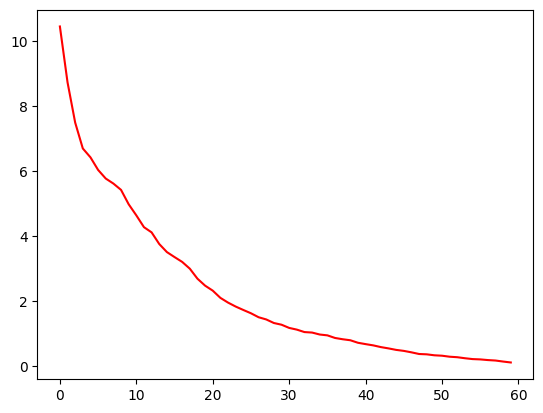

In [ ]:
import random
from sympy.combinatorics.graycode import GrayCode
from sympy.combinatorics.graycode import gray_to_bin
from deap import creator, base, tools, algorithms

import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn.functional as F
from numpy import genfromtxt
import matplotlib.pyplot as plt
import numpy as np

# Load saved model
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(512, num_classes)

#Send model to the GPU device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

weights_tensor = model.fc.weight.data
biases_tensor = model.fc.bias.data

if (("cuda" if torch.cuda.is_available() else "cpu") == "cuda"):
  model.load_state_dict(torch.load('model_SGD.pth'))
else:
  model.load_state_dict(torch.load('model_SGD.pth', map_location=torch.device('cpu')))

model.fc.weight.data = weights_tensor
model.fc.bias.data = biases_tensor

# Switch model to evaluation mode
model.eval()

# Define the loss function
crossentropy = nn.CrossEntropyLoss()

# Randomise weights and biases of last layer
#with torch.no_grad():
#    model.fc.weight.uniform_(-1.0, 1.0)
#    model.fc.bias.uniform_(-1.0, 1.0)

# Convert weights and biases into one vector
weights = extract_last_layer_weights(model).flatten()
weights_length = len(weights)
biases = extract_last_layer_biases(model).flatten()
weights_and_biases = np.concatenate((weights, biases))

# Get a sample from trainloader to be used for fitness function
# Same sample used for all generatios, not 100% sure if this is a good idea
trainloader_iterator = iter(trainloader)
inputs, targets = next(trainloader_iterator)
inputs, targets = inputs.to(device), targets.to(device)

creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

popSize     = 100 #Population size
dimension   = len(weights_and_biases) #Number of decision variable x
numOfBits   = 10 #Number of bits in the chromosomes
iterations  = 300 #Number of generations to be run
dspInterval = 5
nElitists   = 5 #number of elite individuals selected
crossProb   = 0.6
flipProb    = 1. / (dimension * numOfBits) #bit mutate prob
mutateprob  = .8 #mutation prob
maxnum      = 2**numOfBits #absolute max size of number coded by binary list 1,0,0,1,1,....

generation = 0

toolbox = base.Toolbox()

# Attribute generator
#                      define 'attr_bool' to be an attribute ('gene')
#                      which corresponds to integers sampled uniformly
#                      from the range [0,1] (i.e. 0 or 1 with equal
#                      probability)
toolbox.register("attr_bool", random.randint, 0, 1)

# Structure initializers
#                         define 'individual' to be an individual
#                         consisting of numOfBits*dimension 'attr_bool' elements ('genes')
toolbox.register("individual", tools.initRepeat, creator.Individual,
    toolbox.attr_bool, numOfBits*dimension)

# define the pnumOfBitsopulation to be a list of individuals
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Fitness function
def calcFitness(individual):
    # Extract weights and biases from individual
    weights_and_biases = separatevariables(individual)
    weights = np.array(weights_and_biases[0:weights_length]).reshape(num_classes, -1)
    biases = np.array(weights_and_biases[weights_length:len(weights_and_biases)])

    # Inject weights and biases into model
    inject_weights(model, weights)
    inject_biases(model,biases)

    # Obtain model result with injected weights and biases
    out = model(inputs)
    loss = crossentropy(out, targets)
    return loss.item(),

#----------
# Operator registration
#----------
# register the goal / fitness function
toolbox.register("evaluate", calcFitness)

# register the crossover operator
toolbox.register("mate", tools.cxOnePoint)

# register a mutation operator with a probability to
# flip each attribute/gene of 0.05
toolbox.register("mutate", tools.mutFlipBit, indpb=flipProb)

# operator for selecting individuals for breeding the next
# generation: This uses fitness proportionate selection,
# also known as roulette wheel selection
toolbox.register("select", tools.selTournament, fit_attr='fitness')

#----------

# Convert chromosome to real number
# input: list binary 1,0 of length numOfBits representing number using gray coding
# output: real value
def chrom2real(c):
    indasstring=''.join(map(str, c))
    degray=gray_to_bin(indasstring)
    numasint=int(degray, 2) # convert to int from base 2 list
    numinrange=-1+2*numasint/maxnum
    return numinrange

# input: concatenated list of binary variables
# output: real numbers representing those variables
def separatevariables(v):
    weights = []
    for i in range(dimension):
        weights.append(chrom2real(v[i*numOfBits:(i+1)*numOfBits]))
    return weights

def main():
    # create an initial population of individuals (where
    # each individual is a list of integers)
    pop = toolbox.population(n=popSize)

    # Evaluate the entire population
    fitnesses = list(map(toolbox.evaluate, pop))
    for ind, fit in zip(pop, fitnesses):
        ind.fitness.values = fit

    print("  Evaluated %i individuals" % len(pop))

    # Extracting all the fitnesses of
    fits = [ind.fitness.values[0] for ind in pop]

    # Variable keeping track of the number of generations
    g = 0
    bestlist = []

    # Begin the evolution
    while g < iterations:
        # A new generation
        g = g + 1
        generation = g
        print("-- Generation %i --" % g)

        if g%dspInterval ==0:
          inputs, targets = next(trainloader_iterator)
          inputs, targets = inputs.to(device), targets.to(device)

        # Select the next generation individuals
        offspring = tools.selBest(pop, nElitists) + toolbox.select(pop,len(pop)-nElitists,2)
        # Clone the selected individuals
        offspring = list(map(toolbox.clone, offspring))

        # Apply crossover and mutation on the offspring
        # make pairs of offspring for crossing over
        for child1, child2 in zip(offspring[nElitists::2], offspring[nElitists+1::2]):

            # cross two individuals with probability CXPB
            if random.random() < crossProb:
                toolbox.mate(child1, child2)

                # fitness values of the children
                # must be recalculated later
                del child1.fitness.values
                del child2.fitness.values

        for mutant in offspring[nElitists::]:

            # mutate an individual with probability mutateprob
            if random.random() < mutateprob:
                toolbox.mutate(mutant)
                del mutant.fitness.values

        # Evaluate the individuals with an invalid fitness
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # The population is entirely replaced by the offspring
        pop[:] = offspring

        if g%dspInterval ==0:
            # Gather all the fitnesses in one list and print the stats
            fits = [ind.fitness.values[0] for ind in pop]
            bestlist.append(min(fits))


            length = len(pop)
            mean = sum(fits) / length
            sum2 = sum(x*x for x in fits)
            std = abs(sum2 / length - mean**2)**0.5

            print("  Min %s" % min(fits))
            print("  Max %s" % max(fits))
            print("  Avg %s" % mean)
            print("  Std %s" % std)

    print("-- End of (successful) evolution --")

    # Plot graph of best individuals
    plt.plot(np.array(bestlist), 'r')

    best_ind = tools.selBest(pop, 1)[0]
    print("Best individual is %s, %s" % (best_ind, best_ind.fitness.values))
    print("Decoded weights are " , (separatevariables(best_ind)))

    # Extract weights and biases from best individual
    weights_and_biases = separatevariables(best_ind)
    weights = np.array(weights_and_biases[0:weights_length]).reshape(num_classes, -1)
    biases = np.array(weights_and_biases[weights_length:len(weights_and_biases)])

    # Inject weights and biases into model
    inject_weights(model, weights)
    inject_biases(model,biases)


    # Save model with trained fully connected (final) layer
    torch.save(model.state_dict(), 'model_GA.pth')

if __name__ == "__main__":
    main()

# 9. Make predictions with model that has last layer trained with GA

In [ ]:
evaluate_fitness('model_GA.pth')

Total accuracy on the test set: 46.466958598726116


# 10. Train only last layer of the model (on T4 GPU hosted runtime), uses Algorithm 1

cuda
making valid set... 
val size = 1000


/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


run memetic... 
 local search on 10 individuals
gen 3 acc= 9.4 loss= 6.277
 local search on 10 individuals
gen 6 acc= 22.0 loss= 3.931
 local search on 10 individuals
gen 9 acc= 20.4 loss= 3.841
 local search on 10 individuals
gen 12 acc= 25.2 loss= 3.62
 local search on 10 individuals
gen 15 acc= 25.0 loss= 3.723
 local search on 10 individuals
gen 18 acc= 26.8 loss= 4.148
 local search on 10 individuals
gen 21 acc= 24.6 loss= 3.725
 local search on 10 individuals
gen 24 acc= 27.1 loss= 3.584
 local search on 10 individuals
gen 27 acc= 28.0 loss= 3.598
 local search on 10 individuals
gen 30 acc= 27.4 loss= 3.551
 local search on 10 individuals
gen 33 acc= 25.5 loss= 3.84
 local search on 10 individuals
gen 36 acc= 27.3 loss= 3.398
 local search on 10 individuals
gen 39 acc= 26.1 loss= 3.675
 local search on 10 individuals
gen 42 acc= 26.1 loss= 3.522
 local search on 10 individuals
gen 45 acc= 27.7 loss= 3.384
 local search on 10 individuals
gen 48 acc= 28.6 loss= 3.599
 local search 

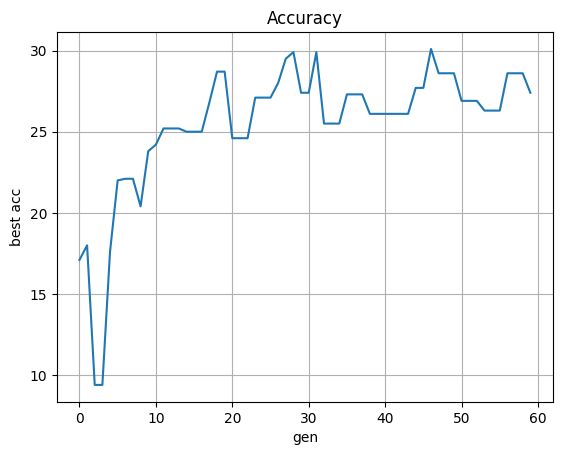

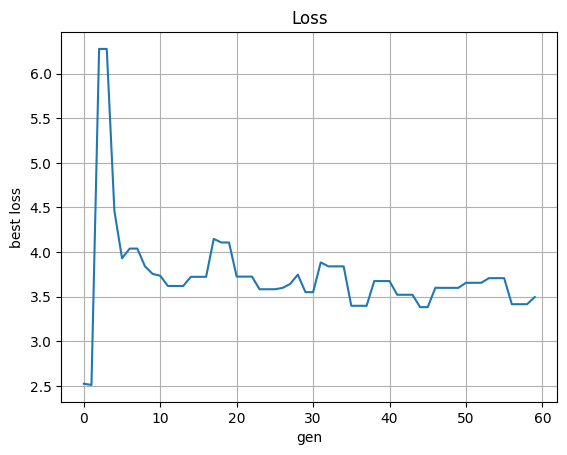

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
from deap import base, creator, tools
import matplotlib.pyplot as plt
import time
from torchvision import models
from torchvision.models import ResNet18_Weights

#  setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(str(device))
num_classes = 10

# load model
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(512, num_classes)
model = model.to(device)

# freeze
for p in model.parameters():
    p.requires_grad = False
for p in model.fc.parameters():
    p.requires_grad = True

def extract_weights_memetic(model):
    w = model.fc.weight.data.cpu().numpy().flatten()
    b = model.fc.bias.data.cpu().numpy().flatten()
    return np.concatenate([w, b])


def inject_weights_memetic(model, arr):
    w = arr[:5120].reshape(10, 512)
    b = arr[5120:5130]
    model.fc.weight.data = torch.FloatTensor(w).to(device)
    model.fc.bias.data = torch.FloatTensor(b).to(device)

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

val_imgs = []
val_labs = []
print("making valid set... ")
for i, (x, y) in enumerate(testloader):
    if i >= 250:
        break
    val_imgs.append(x)
    val_labs.append(y)

val_imgs = torch.cat(val_imgs).to(device)
val_labs = torch.cat(val_labs).to(device)
print("val size =", val_imgs.shape[0])

def evaluate_model_memetic(model):
    model.eval()
    crit = nn.CrossEntropyLoss()
    with torch.no_grad():
        out = model(val_imgs)
        loss = crit(out, val_labs)
        _, pred = torch.max(out, 1)
        acc = (pred == val_labs).sum().item() * 100.0 / len(val_labs)
    return acc, loss.item()


def calcFitness(ind):
    inject_weights_memetic(model, np.array(ind))
    acc, _ = evaluate_model_memetic(model)
    return (acc,)


creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)
toolbox = base.Toolbox()
toolbox.register("attr_float", random.uniform, -0.1, 0.1)
toolbox.register("individual", tools.initRepeat, creator.Individual,toolbox.attr_float, 5130)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", calcFitness)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=0.02, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)


def local_search_adam(ind, iters=10):
    inject_weights_memetic(model, np.array(ind))
    opt = optim.Adam(model.fc.parameters(), lr=0.001)
    crit = nn.CrossEntropyLoss()

    model.train()
    for _ in range(iters):
        for j, (x, y) in enumerate(trainloader):
            if j >= 20:
                break
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            out = model(x)
            loss = crit(out, y)
            loss.backward()
            opt.step()

    nw = extract_weights_memetic(model)
    for i in range(len(ind)):
        ind[i] = nw[i]
    return ind

# hyperparams
POP = 25
GENS = 60
CX = 0.6
MUT = 0.3
ELI = 2
LS_FREQ = 3
LS_P = 0.4

pop = toolbox.population(n=POP)

fits = list(map(toolbox.evaluate, pop))
for i, f in zip(pop, fits):
    i.fitness.values = f

best_acc_hist = []
best_loss_hist = []

total_evals = 0
start = time.time()
print("run memetic... ")

for g in range(GENS):
    elite = tools.selBest(pop, ELI)
    kids = elite + toolbox.select(pop, POP - ELI)
    kids = list(map(toolbox.clone, kids))

    # crossover
    for c1, c2 in zip(kids[ELI::2], kids[ELI+1::2]):
        if random.random() < CX:
            toolbox.mate(c1, c2)
            del c1.fitness.values
            del c2.fitness.values

    # mutate
    for m in kids[ELI:]:
        if random.random() < MUT:
            toolbox.mutate(m)
            del m.fitness.values

    # eval
    bad = [i for i in kids if not i.fitness.valid]
    newfits = list(map(toolbox.evaluate, bad))
    for i, f in zip(bad, newfits):
        i.fitness.values = f
    total_evals += len(bad)

    # local search
    if (g+1) % LS_FREQ == 0:
        kids.sort(key=lambda x: x.fitness.values[0], reverse=True)
        k = int(POP * LS_P)
        print(" local search on", k, "individuals")
        for i in range(k):
            kids[i] = local_search_adam(kids[i], iters=10)
            kids[i].fitness.values = toolbox.evaluate(kids[i])
            total_evals += 1

    pop[:] = kids

    # track acc/loss
    best = tools.selBest(pop, 1)[0]
    inject_weights_memetic(model, np.array(best))
    bacc, bloss = evaluate_model_memetic(model)

    best_acc_hist.append(bacc)
    best_loss_hist.append(bloss)

    if (g+1) % 3 == 0:
        print("gen", g+1, "acc=", round(bacc,2), "loss=", round(bloss,3))

end = time.time()
print("done. time=", end-start, "secs")
print("final acc =", best_acc_hist[-1])
print("final loss =", best_loss_hist[-1])
print("evals =", total_evals)

plt.figure()
plt.plot(best_acc_hist)
plt.xlabel("gen")
plt.ylabel("best acc")
plt.title("Accuracy")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(best_loss_hist)
plt.xlabel("gen")
plt.ylabel("best loss")
plt.title("Loss")
plt.grid(True)
plt.show()

# Save model with trained fully connected (final) layer
torch.save(model.state_dict(), 'model_alg1.pth')

# 11. Make predictions with model that has last layer trained with Algorithm 1

In [ ]:
evaluate_fitness('model_alg1.pth')

Total accuracy on the test set: 27.42


# 12. Train only last layer of the model (on T4 GPU hosted runtime), uses Algorithm 2

Using device: cuda


/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'IndividualDE' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


Initial DE population evaluated
 DE Generation 1 
  Best loss: 2.8552865982055664
 DE Generation 2 
  Best loss: 2.6454787254333496
 DE Generation 3 
  Best loss: 2.6454787254333496
 DE Generation 4 
  Best loss: 2.6454787254333496
 DE Generation 5 
  Best loss: 2.6454787254333496
 DE Generation 6 
  Best loss: 2.6454787254333496
 DE Generation 7 
  Best loss: 2.6454787254333496
 DE Generation 8 
  Best loss: 2.6454787254333496
 DE Generation 9 
  Best loss: 2.6454787254333496
 DE Generation 10 
  Best loss: 2.6454787254333496
 DE Generation 11 
  Best loss: 2.6454787254333496
 DE Generation 12 
  Best loss: 2.6454787254333496
 DE Generation 13 
  Best loss: 2.6454787254333496
 DE Generation 14 
  Best loss: 2.6454787254333496
 DE Generation 15 
  Best loss: 2.6454787254333496
 DE Generation 16 
  Best loss: 2.64506459236145
 DE Generation 17 
  Best loss: 2.5455803871154785
 DE Generation 18 
  Best loss: 2.5110015869140625
 DE Generation 19 
  Best loss: 2.508273124694824
 DE Generat

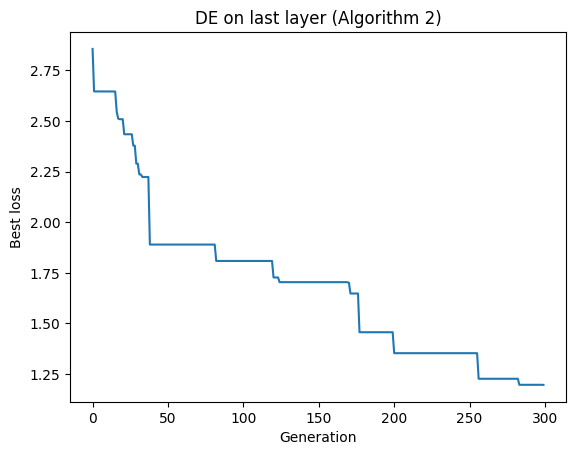

In [ ]:
import random
import numpy as np
from deap import base, creator, tools

# Reload base model, reset last layer to initial random state
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(512, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Store fresh random fc weights and biases
weights_tensor = model.fc.weight.data.clone()
biases_tensor = model.fc.bias.data.clone()

# Load the SGD-trained backbone
if device.type == "cuda":
    model.load_state_dict(torch.load('model_SGD.pth'))
else:
    model.load_state_dict(torch.load('model_SGD.pth', map_location=torch.device('cpu')))

# Overwrite fc with fresh random layer (so only last layer is "untrained")
model.fc.weight.data = weights_tensor
model.fc.bias.data = biases_tensor

model.eval()
crossentropy = nn.CrossEntropyLoss()

# Build flat vector [all weights, then all biases]
weights = extract_last_layer_weights(model).flatten()
weights_length = len(weights)
biases = extract_last_layer_biases(model).flatten()
weights_and_biases = np.concatenate((weights, biases))

#  setup device
print("Using device:", device)


batch_size = 128

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

dimension = len(weights_and_biases)

# One minibatch for fitness evaluation (like GA code)
trainloader_iterator = iter(trainloader)
inputs, targets = next(trainloader_iterator)
inputs, targets = inputs.to(device), targets.to(device)

toolbox_de = base.Toolbox()

toolbox_de.inputs = inputs
toolbox_de.targets = targets
toolbox_de.trainloader_iterator = trainloader_iterator

# Use the existing FitnessMin from GA:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("IndividualDE", list, fitness=creator.FitnessMin)


# Bounds for last-layer weights
X_MIN = -0.1
X_MAX = 0.1

def init_gene():
    return random.uniform(X_MIN, X_MAX)

toolbox_de.register("attr_float", init_gene)
toolbox_de.register("individual", tools.initRepeat, creator.IndividualDE,
                    toolbox_de.attr_float, n=dimension)
toolbox_de.register("population", tools.initRepeat, list, toolbox_de.individual)

def de_calc_fitness(individual):
    # split back into weights and biases
    w_flat = np.array(individual[0:weights_length])
    b_flat = np.array(individual[weights_length:])

    w = w_flat.reshape(num_classes, -1)
    b = b_flat

    # inject into model
    inject_weights(model, w)
    inject_biases(model, b)

    # compute loss on current minibatch
    out = model(toolbox_de.inputs)
    loss = crossentropy(out, toolbox_de.targets)
    return (loss.item(),)

toolbox_de.register("evaluate", de_calc_fitness)

# Hyperparameters for DE
POP_SIZE_DE = 200
NUM_GENERATIONS_DE = 300
F = 0.8
CR_START = 0.9  # CR at the first generation
CR_END   = 0.2  # CR at the last generation
dspInterval = 10  # how often to refresh minibatch + print stats

def run_de():

    # initial population
    population = toolbox_de.population(n=POP_SIZE_DE)

    # evaluate
    for i in range(POP_SIZE_DE):
        ind = population[i]
        ind.fitness.values = toolbox_de.evaluate(ind)

    print("Initial DE population evaluated")

    best_list = []

    for gen in range(NUM_GENERATIONS_DE):
        print(f" DE Generation {gen+1} ")

        # compute CR_current for this generation (linear decay)
        if NUM_GENERATIONS_DE > 1:
            CR_current = CR_START - (gen / (NUM_GENERATIONS_DE - 1)) * (CR_START - CR_END)
        else:
            CR_current = CR_START


        # refresh minibatch occasionally
        if (gen + 1) % dspInterval == 0:
            try:
                inputs, targets = next(toolbox_de.trainloader_iterator)
            except StopIteration:
                toolbox_de.trainloader_iterator = iter(trainloader)
                inputs, targets = next(toolbox_de.trainloader_iterator)

            inputs, targets = inputs.to(device), targets.to(device)

            # update toolbox batch
            toolbox_de.inputs = inputs
            toolbox_de.targets = targets


        new_population = []

        for i in range(POP_SIZE_DE):
            # choose a, b, c distinct from i
            idxs = []
            for k in range(POP_SIZE_DE):
                if k != i:
                    idxs.append(k)

            a_idx = random.choice(idxs)
            idxs.remove(a_idx)

            b_idx = random.choice(idxs)
            idxs.remove(b_idx)

            c_idx = random.choice(idxs)

            a = population[a_idx]
            b = population[b_idx]
            c = population[c_idx]

            # mutation: v = a + F*(b - c)
            v = creator.IndividualDE([0.0]*dimension)
            for d in range(dimension):
                val = a[d] + F * (b[d] - c[d])
                if val < X_MIN:
                    val = X_MIN
                if val > X_MAX:
                    val = X_MAX
                v[d] = val

            # crossover
            trial = creator.IndividualDE([0.0]*dimension)
            for d in range(dimension):
                r = random.random()
                if r < CR_current:
                    trial[d] = v[d]
                else:
                    trial[d] = population[i][d]

            # evaluate trial
            trial.fitness.values = toolbox_de.evaluate(trial)
            target = population[i]

            # selection (minimise loss)
            if trial.fitness.values[0] <= target.fitness.values[0]:
                new_population.append(trial)
            else:
                new_population.append(target)

        population = new_population

        # get best in this generation
        best_idx = 0
        for i in range(POP_SIZE_DE):
            if population[i].fitness.values[0] < population[best_idx].fitness.values[0]:
                best_idx = i

        best_loss = population[best_idx].fitness.values[0]
        best_list.append(best_loss)
        print("  Best loss:", best_loss)

    # after all generations: final best
    best_idx = 0
    for i in range(POP_SIZE_DE):
        if population[i].fitness.values[0] < population[best_idx].fitness.values[0]:
            best_idx = i

    best_ind = population[best_idx]
    print("DE finished. Best loss:", best_ind.fitness.values[0])

    # decode best individual into weights and biases
    best_w_flat = np.array(best_ind[0:weights_length])
    best_b_flat = np.array(best_ind[weights_length:])

    best_w = best_w_flat.reshape(num_classes, -1)
    best_b = best_b_flat

    inject_weights(model, best_w)
    inject_biases(model, best_b)

    # save DE-trained last layer
    torch.save(model.state_dict(), 'model_alg2.pth')

    # plot loss curve
    plt.figure()
    plt.plot(best_list)
    plt.xlabel("Generation")
    plt.ylabel("Best loss")
    plt.title("DE on last layer (Algorithm 2)")
    plt.show()

    return best_list

best_list_de = run_de()


# 13. Make predictions with model that has last layer trained with Algorithm 2

In [ ]:
evaluate_fitness('model_alg2.pth')

Total accuracy on the test set: 47.910000000000004


# 14. Train only last layer of the model (on T4 GPU hosted runtime), uses NSGA2

In [ ]:
import random
import numpy as np
from deap import base, creator, tools, algorithms
import torch
import torchvision.models as models

# model setup
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = torch.nn.Linear(512, num_classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

try:
  if device.type == "cuda":
    model.load_state_dict(torch.load('model_SGD.pth'))
  else:
    model.load_state_dict(torch.load('model_SGD.pth', map_location=torch.device('cpu')))
except FileNotFoundError:
  print("file aint there bruv")

weights_tensor = model.fc.weight.data
biases_tensor = model.fc.bias.data
with torch.no_grad():
  model.fc.weight.uniform_(-0.1, 0.1)
  model.fc.bias.uniform_(-0.1, 0.1)

model.eval()

print("loading into vram")

try:
  trainset
except NameError:
  import torchvision.transforms as transforms
  import torchvision.datasets as datasets
  transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
  trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

gpu_batch_size = 64
temp_loader = torch.utils.data.DataLoader(trainset, batch_size=gpu_batch_size, shuffle=True, num_workers=0)
data_iter = iter(temp_loader)
inputs_gpu, targets_gpu = next(data_iter)

inputs_gpu = inputs_gpu.to(device)
targets_gpu = targets_gpu.to(device)
print(f"loaded data to vram: {inputs_gpu.shape} size: {inputs_gpu.element_size() * inputs_gpu.nelement() / 1024**2:.2f} MB")

def extract_last_layer_weights(model):
    return model.fc.weight.data.cpu().numpy()

def extract_last_layer_biases(model):
    return model.fc.bias.data.cpu().numpy()

def inject_weights(model, weight_array):
    w_tensor = torch.from_numpy(weight_array).float().to(device)
    model.fc.weight.data.copy_(w_tensor)

def inject_biases(model, biases_array):
    b_tensor = torch.from_numpy(biases_array).float().to(device)
    model.fc.bias.data.copy_(b_tensor)

weights = extract_last_layer_weights(model).flatten()
weights_length = len(weights)
biases = extract_last_layer_biases(model).flatten()
weights_and_biases = np.concatenate((weights, biases))
dimension = len(weights_and_biases)

if hasattr(creator, "FitnessMulti_NSGA"):
  del creator.FitnessMulti_NSGA
if hasattr(creator, "IndividualNSGA2"):
  del creator.IndividualNSGA2
creator.create("FitnessMulti_NSGA", base.Fitness, weights=(1.0, -1.0))
creator.create("IndividualNSGA2", list, fitness=creator.FitnessMulti_NSGA)


toolbox_nsga = base.Toolbox()
toolbox_nsga.register("attr_float", random.uniform, -0.1, 0.1)
toolbox_nsga.register("individual", tools.initRepeat, creator.IndividualNSGA2, toolbox_nsga.attr_float, n=dimension)
toolbox_nsga.register("population", tools.initRepeat, list, toolbox_nsga.individual)

def evaluate_nsga2(individual):
  w_flat = np.array(individual[0:weights_length])
  b_flat = np.array(individual[weights_length:])

  w_matrix = w_flat.reshape(num_classes, -1)
  w_tensor = torch.from_numpy(w_matrix).float().to(device)
  b_tensor = torch.from_numpy(b_flat).float().to(device)
  model.fc.weight.data = w_tensor
  model.fc.bias.data = b_tensor

  with torch.no_grad():
    outputs = model(inputs_gpu)
    pred = outputs.argmax(dim=1, keepdim=True)
    correct = pred.eq(targets_gpu.view_as(pred)).sum().item()
    acc = correct / len(targets_gpu)
    l2_reg = np.sum(np.array(individual)**2)
  return acc, l2_reg

toolbox_nsga.register("evaluate", evaluate_nsga2)
toolbox_nsga.register("mate", tools.cxSimulatedBinaryBounded, low=-1.0, up=1.0, eta=20.0)
toolbox_nsga.register("mutate", tools.mutGaussian, mu=0.0, sigma=0.02, indpb=0.1)
toolbox_nsga.register("select", tools.selNSGA2)

def main_nsga2():
  POP_SIZE = 150
  NGEN = 67
  CXPB = 0.9
  MUTPB = 0.1

  pop = toolbox_nsga.population(n=POP_SIZE)
  invalid_ind = [ind for ind in pop if not ind.fitness.valid]
  fitnesses = map(toolbox_nsga.evaluate, invalid_ind)
  for ind, fit in zip(invalid_ind, fitnesses):
    ind.fitness.values = fit

  print(f"NSGA2 is running with pop={POP_SIZE}, ngen={NGEN}, CXPB={CXPB}, MUTPB={MUTPB}")

  for gen in range(NGEN):
    offspring = algorithms.varOr(pop, toolbox_nsga, lambda_=POP_SIZE, cxpb=CXPB, mutpb=MUTPB)

    invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
    fitnesses = map(toolbox_nsga.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
      ind.fitness.values = fit

    pop = toolbox_nsga.select(pop + offspring, POP_SIZE)

    if gen % 5 == 0:
      fits_acc = [ind.fitness.values[0] for ind in pop]
      print(f"generation {gen}: max accuracy {max(fits_acc):.4f}")

  best_ind = sorted(pop, key=lambda x: x.fitness.values, reverse=True)[0]
  print(f"Best Accuracy: {best_ind.fitness.values[0]:.4f}")

  w_flat = np.array(best_ind[0:weights_length])
  b_flat = np.array(best_ind[weights_length:])
  inject_weights(model, w_flat.reshape(num_classes, -1))
  inject_biases(model, b_flat)
  torch.save(model.state_dict(), 'model_NSGA2.pth')
  print("model saved")
  return pop

if __name__ == "__main__":
  final_nsga_pop = main_nsga2()


loading into vram
loaded data to vram: torch.Size([64, 3, 32, 32]) size: 0.75 MB
NSGA2 is running with pop=150, ngen=67, CXPB=0.9, MUTPB=0.1
generation 0: max accuracy 0.3281
generation 5: max accuracy 0.3750
generation 10: max accuracy 0.4688
generation 15: max accuracy 0.5000
generation 20: max accuracy 0.5625
generation 25: max accuracy 0.5938
generation 30: max accuracy 0.6094
generation 35: max accuracy 0.6094
generation 40: max accuracy 0.6562
generation 45: max accuracy 0.6875
generation 50: max accuracy 0.6875
generation 55: max accuracy 0.7031
generation 60: max accuracy 0.7031
generation 65: max accuracy 0.7656
Best Accuracy: 0.7656
model saved


## 15. Make predictions with model that has last layer trained with NSGA2

In [ ]:
evaluate_fitness('model_NSGA2.pth')

Total accuracy on the test set: 41.0


Graph plot for NSGA2 pareto front

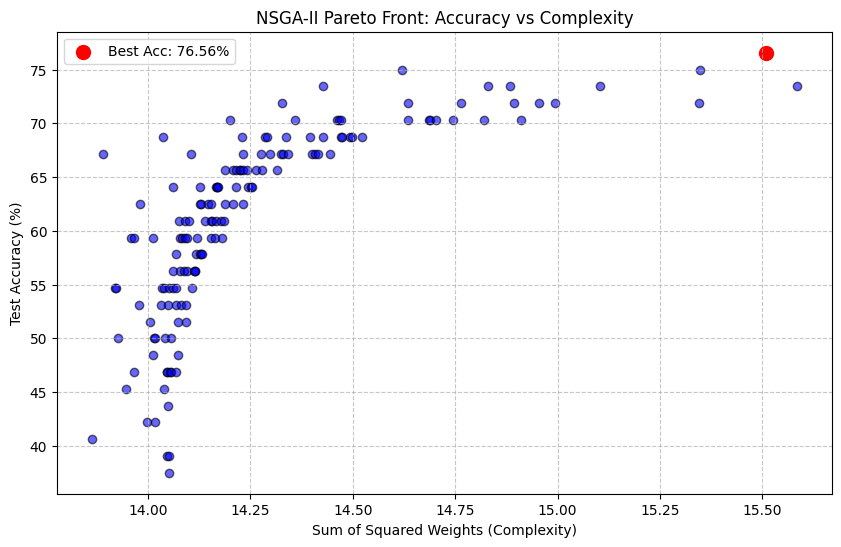

graph generated and saved as png


In [ ]:
import matplotlib.pyplot as plt
import numpy as py


accuracies = [ind.fitness.values[0] * 100 for ind in final_nsga_pop]
reg_sums = [ind.fitness.values[1] for ind in final_nsga_pop]

plt.figure(figsize=(10, 6))
plt.scatter(reg_sums, accuracies, c='blue', alpha=0.6, edgecolors='black')
plt.xlabel('Sum of Squared Weights (Complexity)')
plt.ylabel('Test Accuracy (%)')
plt.title('NSGA-II Pareto Front: Accuracy vs Complexity')
plt.grid(True, linestyle='--', alpha=0.7)
best_idx = np.argmax(accuracies)
plt.scatter(reg_sums[best_idx], accuracies[best_idx], c='red', s=100, label=f'Best Acc: {accuracies[best_idx]:.2f}%')
plt.legend()
plt.savefig('nsga_pareto_front.png')
plt.show()
print("graph generated and saved as png")

Section 4: A numerical result section including a description of the experimental setup and
detailing all the parameters set in the experiments (5%). Then present the results in a Table that
compares the difference in accuracy for the three methods (5%):
o A gradient descent method
o A population-based heuristic, e.g., GA, PSO etc.
o Your chosen algorithm 1 – can be something covered in the module.
o Your chosen algorithm 2 – ideally something you found yourself through research, or a
customised variant on something covered in module.
Include one figure depicting an example of performance trend of the three methods (i.e.,
accuracy versus the number of evaluations of the objective function). One figure should be
enough, charting three learning methods on the same graph. (5%). Add two to four paragraphs
to comment on the results and discuss the relative advantages of the approaches under
examination and explain why one may perform better than another (10%). (total Mark 25%)
